In [24]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# p_astro > 0.99 yapinca elimde 27 veri kaliyor o yuzden %50den buyuk olarak filtreledim
df = pd.read_csv('gw_data.csv')
df['mass_ratio'] = df['mass_2_source'] / df['mass_1_source']
df_model = df[df['p_astro'] >0.5].dropna(subset=['chi_eff'] + ['luminosity_distance'] + ['mass_1_source'] + ['mass_2_source'] + ['total_mass_source'] + ['chirp_mass_source'] + ['final_mass_source']+ ['network_matched_filter_snr'] + ['redshift']+ ['far'] + ['mass_ratio'])
y = df_model['network_matched_filter_snr']


In [4]:
#tek tek fit deneme SNR'yi bulmak icin

# First fitting
aday1 = df_model['total_mass_source']
aday1 = sm.add_constant(aday1)
model1 = sm.OLS(y, aday1).fit()
print(model1.summary())


                                OLS Regression Results                                
Dep. Variable:     network_matched_filter_snr   R-squared:                       0.000
Model:                                    OLS   Adj. R-squared:                 -0.004
Method:                         Least Squares   F-statistic:                   0.05819
Date:                        Wed, 12 Aug 2026   Prob (F-statistic):              0.810
Time:                                11:29:45   Log-Likelihood:                -856.42
No. Observations:                         259   AIC:                             1717.
Df Residuals:                             257   BIC:                             1724.
Df Model:                                   1                                         
Covariance Type:                    nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

In [7]:
# Second fitting 
aday1_2 = pd.concat([df_model['total_mass_source'], df_model['luminosity_distance']], axis=1)
aday1_2 = sm.add_constant(aday1_2)
model2 = sm.OLS(y,aday1_2).fit()
print(model2.summary())


                                OLS Regression Results                                
Dep. Variable:     network_matched_filter_snr   R-squared:                       0.257
Model:                                    OLS   Adj. R-squared:                  0.251
Method:                         Least Squares   F-statistic:                     44.32
Date:                        Wed, 12 Aug 2026   Prob (F-statistic):           2.97e-17
Time:                                11:33:53   Log-Likelihood:                -817.95
No. Observations:                         259   AIC:                             1642.
Df Residuals:                             256   BIC:                             1653.
Df Model:                                   2                                         
Covariance Type:                    nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------

In [8]:
# Third fitting, distancei ters ceviricem korelasyon negatif
df_model['inv_ld'] = 1/ df_model['luminosity_distance']
aday1_3 = pd.concat([df_model['total_mass_source'], df_model['inv_ld']], axis=1)
aday1_3 = sm.add_constant(aday1_3)
model3 = sm.OLS(y,aday1_3).fit()
print(model3.summary())

                                OLS Regression Results                                
Dep. Variable:     network_matched_filter_snr   R-squared:                       0.386
Model:                                    OLS   Adj. R-squared:                  0.381
Method:                         Least Squares   F-statistic:                     80.48
Date:                        Wed, 12 Aug 2026   Prob (F-statistic):           7.65e-28
Time:                                11:35:41   Log-Likelihood:                -793.28
No. Observations:                         259   AIC:                             1593.
Df Residuals:                             256   BIC:                             1603.
Df Model:                                   2                                         
Covariance Type:                    nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

In [11]:
# 4th fitting, chi_eff ekliycem
aday1_3_4 = pd.concat([df_model['total_mass_source'], df_model['inv_ld'], df_model['chi_eff']], axis=1)
aday1_3_4 = sm.add_constant(aday1_3_4)
model4 = sm.OLS(y,aday1_3_4).fit()
print(model4.summary())

#chi_eff bir ise yaramadi

                                OLS Regression Results                                
Dep. Variable:     network_matched_filter_snr   R-squared:                       0.390
Model:                                    OLS   Adj. R-squared:                  0.383
Method:                         Least Squares   F-statistic:                     54.39
Date:                        Wed, 12 Aug 2026   Prob (F-statistic):           3.27e-27
Time:                                11:39:21   Log-Likelihood:                -792.39
No. Observations:                         259   AIC:                             1593.
Df Residuals:                             255   BIC:                             1607.
Df Model:                                   3                                         
Covariance Type:                    nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

Ortalama Sapma (MAE): 3.64 Mpc
Başarı Skoru (R2)   : 0.37


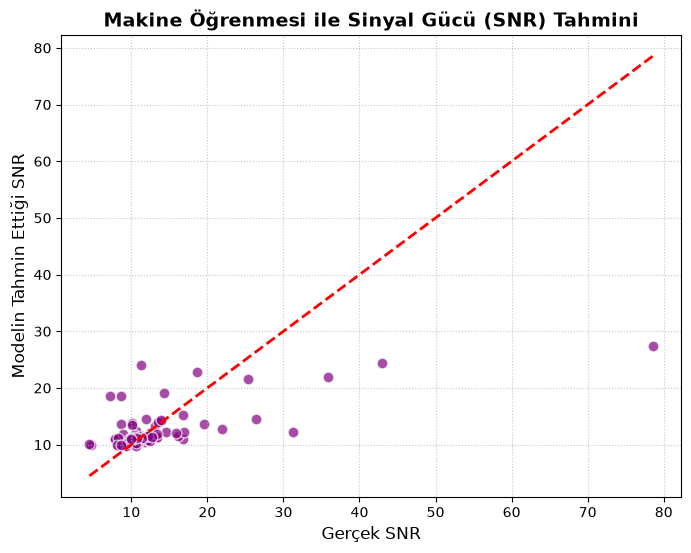

In [22]:
# bu son OLS'ye gore bir random forest ML deniycem

x_ml = df_model[['total_mass_source','luminosity_distance', 'mass_ratio']]
y_ml = df_model['network_matched_filter_snr']

x_train , x_test , y_train , y_test = train_test_split(x_ml, y_ml , test_size = 0.3 , random_state=42)

rf_model = RandomForestRegressor(n_estimators= 100 , max_depth=5, random_state=42)
rf_model.fit(x_train, y_train)

rf_tahminler = rf_model.predict(x_test)

print(f"Ortalama Sapma (MAE): {mean_absolute_error(y_test, rf_tahminler):.2f} Mpc")
print(f"Başarı Skoru (R2)   : {r2_score(y_test, rf_tahminler):.2f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_tahminler, color='purple', alpha=0.7, edgecolors='white', s=60)
plt.plot([y_ml.min(), y_ml.max()], [y_ml.min(), y_ml.max()], color='red', linestyle='dashed', lw=2)

plt.xlabel('Gerçek SNR', fontsize=12)
plt.ylabel('Modelin Tahmin Ettiği SNR', fontsize=12)
plt.title('Makine Öğrenmesi ile Sinyal Gücü (SNR) Tahmini', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

#pek basarili olmadi, sanirim sinyallerin gelis acisi da onemli oldugu icin

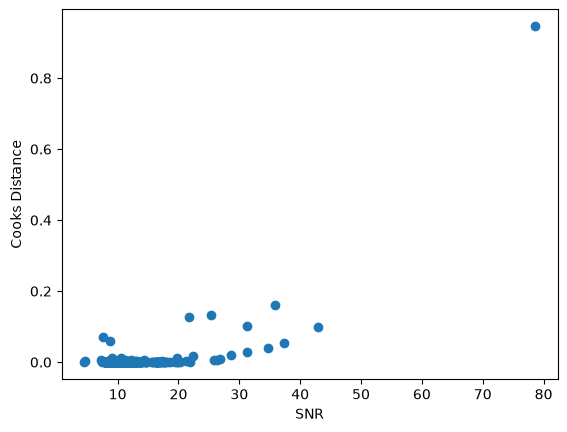

In [25]:
# Cook's distance
# Fitting: SNR

X = df_model[['total_mass_source','luminosity_distance', 'mass_ratio']]
X = sm.add_constant(X)
model = sm.OLS(y,X).fit()
np.set_printoptions(suppress=True)

#create instance of influence
influence = model.get_influence()

#obtain Cook's distance for each observation
cooks = influence.cooks_distance

#display Cook's distances
plt.scatter(y, cooks[0])
plt.xlabel('SNR')
plt.ylabel('Cooks Distance')
plt.show()

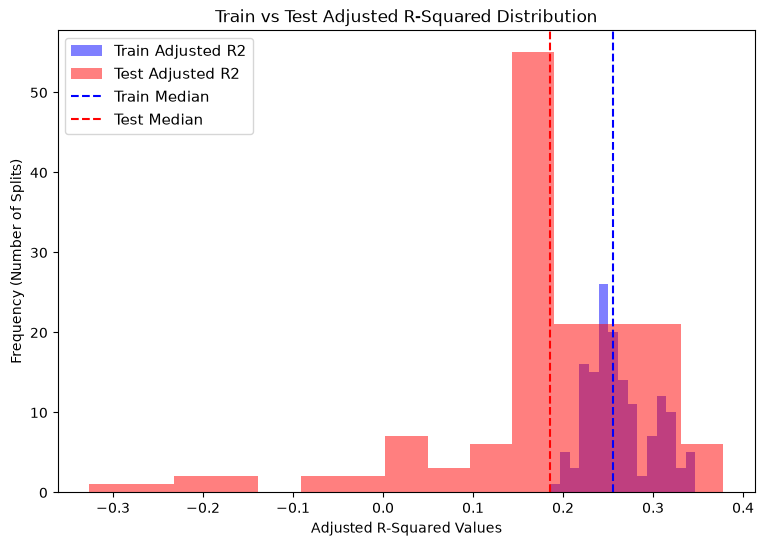

In [27]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import r2_score

#repeatedKfold ile deniycem

Y = df_model['network_matched_filter_snr']
X = df_model[['total_mass_source','luminosity_distance']]

R2_train = []
R2_test = []

rkf = RepeatedKFold(n_splits=3, n_repeats=50, random_state=10)
for train_index, test_index in rkf.split(X):
    X_train = X.iloc[train_index]
    Y_train = Y.iloc[train_index]
    X_test = X.iloc[test_index]
    Y_test = Y.iloc[test_index]

    # Modeli ve fiti olusturma
    X_train = sm.add_constant(X_train)
    model = sm.OLS(Y_train , X_train).fit()
    R2_train.append(model.rsquared_adj)
    
    # Test setinden tahmin
    X_test = sm.add_constant(X_test)
    Y_tahmin = model.predict(X_test)
    # Normal Rkare degeri
    R2score_test = r2_score(Y_test, Y_tahmin)
    # Adjusted Rkare degeri
    n = len(Y_test)
    p = 2           # mass,ld
    R2score_test_adj = 1 - ((1 - R2score_test) * (n - 1) / (n - p - 1))
    R2_test.append(R2score_test_adj)

plt.figure(figsize = (9,6))
plt.hist(R2_train, bins=15, alpha=0.5, color='blue', label='Train Adjusted R2')
plt.hist(R2_test, bins=15, alpha=0.5, color='red', label='Test Adjusted R2') 
median_train = np.median(R2_train)
median_test = np.median(R2_test)
plt.axvline(median_train, color='blue', linestyle='--', label='Train Median')
plt.axvline(median_test, color='red', linestyle='--',label='Test Median')
plt.xlabel('Adjusted R-Squared Values')
plt.ylabel('Frequency (Number of Splits)')
plt.title('Train vs Test Adjusted R-Squared Distribution')
plt.legend(loc='upper left', fontsize=11)
plt.show()

